# Laboratório 5 – Regressão (gabarito) [<img src="https://raw.githubusercontent.com/urielmoreirasilva/ICX532/main/labs_gabs/Laborat%C3%B3rio%205%20%E2%80%93%20Regress%C3%A3o%20%28gabarito%29/images/colag_logo.svg" style="float: right; margin-right: 0%; vertical-align: middle; width: 6.5%;">](https://colab.research.google.com/github/urielmoreirasilva/ICX532/blob/main/labs_gabs/Laborat%C3%B3rio%205%20%E2%80%93%20Regress%C3%A3o%20%28gabarito%29/Laborat%C3%B3rio%205%20%E2%80%93%20Regress%C3%A3o%20%28gabarito%29.ipynb) [<img src="https://raw.githubusercontent.com/urielmoreirasilva/ICX532/main/labs_gabs/Laborat%C3%B3rio%205%20%E2%80%93%20Regress%C3%A3o%20%28gabarito%29/images/github_logo.svg" style="float: right; margin-right: 0%; vertical-align: middle; width: 3.25%;">](https://github.com/urielmoreirasilva/ICX532/blob/main/labs_gabs/Laborat%C3%B3rio%205%20%E2%80%93%20Regress%C3%A3o%20%28gabarito%29/Laborat%C3%B3rio%205%20%E2%80%93%20Regress%C3%A3o%20%28gabarito%29.ipynb)

Bem-vindo ao Laboratório 5, o último laboratório dessa disciplina! Neste laboratório, vamos praticar um pouco com a técnica de regressão linear.

Você deve concluir todo este laboratório e enviá-lo ao Moodle até às 23h59 da data de vencimento.

### Referências
- [CIT: Capítulo 15](https://inferentialthinking.com/)
- Aulas: Tópico 18. 

Material adaptado do [DSC10 (UCSD)](https://dsc10.com/) por [Flavio Figueiredo (DCC-UFMG)](https://flaviovdf.io/fcd/) e [Uriel Silva (DEST-UFMG)](https://urielmoreirasilva.github.io)

In [1]:
## Imports para esse laboratório
import numpy as np
import pandas as bpd

## Opções do MatplotLib 
import matplotlib.pyplot as plt
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Quão fiel é o Old Faithful?

(O título inteligente vem [daqui](http://web.pdx.edu/~jfreder/M212/oldfaithful.pdf).)

Old Faithful é um gêiser no Parque Nacional de Yellowstone, no centro dos Estados Unidos.  É famoso por entrar em erupção regularmente.  Você pode ver um vídeo abaixo.

In [3]:
from IPython.display import YouTubeVideo

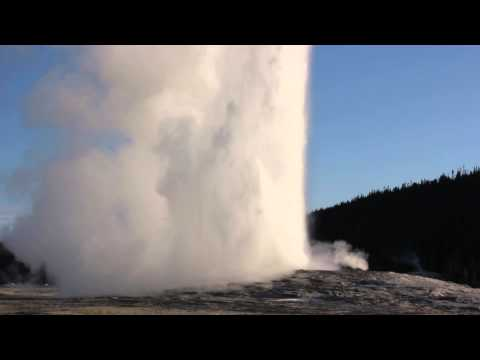

In [4]:
## Rode essa célula.
YouTubeVideo('wE8NDuzt8eg')

Algumas das erupções do Old Faithful duram mais do que outras.  Quando tem uma erupção longa, geralmente há uma espera mais longa até a próxima erupção.

Se você visitar Yellowstone, você pode querer **prever quando a próxima erupção acontecerá**, para que você possa ver o resto do parque e ver o gêiser quando ele estiver em erupção.  Neste laboratório, usaremos um conjunto de dados sobre durações de erupções e tempos de espera para ver se podemos fazer tais previsões com precisão com regressão linear.

O conjunto de dados possui uma linha para cada erupção observada.  Inclui as seguintes colunas:
- `'duration'`: Duração da erupção, em minutos.
- `'wait'`: Tempo entre esta erupção e a próxima, também em minutos.

Execute a próxima célula para carregar o conjunto de dados.

In [5]:
faithful = bpd.read_csv('https://raw.githubusercontent.com/dsc-courses/dsc10-2023-wi/main/labs_gabs/lab07/data/faithful.csv')
faithful

HTTPError: HTTP Error 404: Not Found

Gostaríamos de usar a regressão linear para fazer previsões sobre o tempo de espera dada uma duração, mas isso não funcionará bem se os dados não estiverem relacionados, aproximadamente, linearmente.  Para verificar isso, devemos olhar os dados.

**Pergunta 1.1.** Faça um gráfico de dispersão dos dados.  É convencional colocar a coluna que tentaremos prever no **eixo vertical** e a outra coluna no eixo horizontal.

In [ ]:
# Faça seu gráfico de dispersão.
...

**Pergunta 1.2.** Observe o gráfico de dispersão. A duração da erupção e o tempo de espera estão aproximadamente linearmente relacionados?  Se sim, a relação entre eles é negativa ou positiva?  Atribua 1, 2 ou 3 à variável `faith_q2` abaixo.
1. A duração da erupção e o tempo de espera não estão aproximadamente linearmente relacionados.
2. A duração da erupção e o tempo de espera estão aproximadamente linearmente relacionados. A relação entre eles é negativa.
3. A duração da erupção e o tempo de espera estão aproximadamente linearmente relacionados. A relação entre eles é positiva.

In [ ]:
faith_q2 = ...

O gráfico de dispersão sugere que é razoável usar regressão linear para analisar esses dados.

A seguir, gostaríamos de representar graficamente os dados em unidades padrão.  Lembre-se de que, se `nums` for uma série de números, então

```py
(nums - nums.mean()) / np.std(nums)
```

é uma série desses números em unidades padrão.

**Pergunta 1.3.** Calcule a média e o desvio padrão das durações das erupções e dos tempos de espera.  Em seguida, crie um DataFrame chamado `faithful_su` contendo as durações da erupção e os tempos de espera em **unidades padrão**. As colunas devem ser nomeadas `'duration_su'` e `'wait_su'`, respectivamente. Note que `su` vem de *standard units*, unidades padrão.

*Nota*: Você deve usar `np.std` para calcular o desvio padrão.

In [ ]:
duration_mean = ...
duration_std = ...
wait_mean = ...
wait_std = ...

faithful_su = ...
faithful_su

**Pergunta 1.4.** Crie um gráfico de dispersão dos dados novamente, mas desta vez em unidades padrão.

In [ ]:
# Faça seu gráfico de dispersão.
...

Você notará que este gráfico é exatamente igual ao anterior!  Os dados são realmente diferentes, mas os gráficos parecem iguais porque os eixos são dimensionados de forma diferente.  O método `.plot` dimensiona automaticamente os eixos para que os dados preencham o espaço disponível.  Isso significa que é importante ler os eixos do gráfico!

**Pergunta 1.5.** Entre os seguintes números, qual você acha que está mais próximo da correlação entre a duração da erupção e o tempo de espera neste conjunto de dados: `-1`, `0` ou `1`? Atribua sua resposta a `correlation_guess`.

In [ ]:
correlation_guess = ...

Agora, você realmente calculará a correlação entre duração e tempo de espera. Para ajudá-lo a fazer isso, definimos uma função `standard_units` que recebe um array ou série de números e retorna uma cópia na qual todos os valores estão em unidades padrão:

In [ ]:
def standard_units(any_numbers):
    '''Convert an array or Series of numbers to standard units.'''
    return (any_numbers - any_numbers.mean()) / np.std(any_numbers)

**Questão 1.6.** Conclua a implementação da função `correlation`, que recebe um DataFrame `df` e dois nomes de coluna `x` e `y` e retorna a correlação entre as duas colunas. Em seguida, use sua função para encontrar a correlação entre duração e tempo de espera e atribua-a à variável `r`.

*Dicas*:
- Faz diferença se calcularmos a correlação entre `'duration_su'` e `'wait_su'` ou `'duration'` e `'wait'`?
- [CIT 15.1.2.](https://inferentialthinking.com/chapters/15/1/Correlation.html#calculating-r) explica como fazer isso, se você tiver problemas.

In [ ]:
def correlation(df, x, y):
    ...
r = ...
r

## 2. A linha de regressão

Lembre-se de que a correlação é a *inclinação* da linha de regressão quando os dados são colocados em unidades padrão.

A próxima célula traça a **linha de regressão em unidades padrão**:

$$\text{wait_su} = r \times \text{duration_su}$$

Em seguida, sobreponha a linha a um gráfico dos dados originais (em unidades padrão) para comparação.  (Você não precisa entender completamente o código, **basta executá-lo**.)

In [ ]:
def plot_data_and_line(dataset, x, y, point_0, point_1):
    '''Makes a scatter plot of the dataset, along with a line passing through two points.'''
    dataset.plot(kind='scatter', x=x, y=y, label='data', figsize=(10, 5))
    xs, ys = zip(point_0, point_1)
    plt.plot(xs, ys, label='regression line', color='orange')
    plt.xlabel('duration')
    plt.ylabel('wait')
    plt.legend()

plot_data_and_line(faithful_su,
                   'duration_su',
                   'wait_su',
                   [-2, -2 * r],
                   [2, 2 * r])

Como você pegaria um ponto em unidades padrão e o converteria de volta em unidades originais?  Teríamos que "esticar" sua posição horizontal em `duration_std` e sua posição vertical em `wait_std`.

Isso significa que a mesma coisa aconteceria com a inclinação da reta.

Esticar uma linha **horizontalmente** a torna menos íngreme, então **dividimos a inclinação por um fator de alongamento horizontal**.  Esticar uma linha **verticalmente** a torna mais íngreme, então **multiplicamos a inclinação por um fator de alongamento vertical**. (Qual valor descreve a distribuição das durações? Qual valor descreve a distribuição dos tempos de espera?)

**Pergunta 2.1.** Qual é a inclinação da reta de regressão em unidades originais?

*Dica*: Se a explicação de "alongamento" não for intuitiva, consulte [CIT 15.2.5](https://inferentialthinking.com/chapters/15/2/Regression_Line.html#the-equation-of-the-regression-line).

In [ ]:
slope = ...
slope

Sabemos que a linha de regressão passa pelo ponto $(\verb|duration_mean|, \verb|wait_mean|)$.  Então, agora sabemos a inclinação da reta de regressão e um ponto por onde ela passa. Você deve se lembrar da forma ponto-coeficiente angular de uma reta da álgebra do ensino médio. Essa equação da reta é:

$$\text{tempo de espera} - \verb|wait_mean| = \texttt{inclinação} \times (\text{duração da erupção} - \verb|duration_mean|)$$

**Questão 2.2.** Reorganize a equação acima para encontrar a interceptação da reta. Em seguida, atribua `intercept` como a interceptação da linha de regressão.

*Dica*: Pense em $\text{duração da erupção}$ como $x$ e $\text{tempo de espera}$ como $y$. Tente reorganizar a equação acima para ficar na forma $y = mx + b$, onde $b$ é o intercept.

In [ ]:
intercept = ...
intercept

## 3. Investigando a linha de regressão
A inclinação e a interceptação informam exatamente a aparência da linha de regressão.

$$\text{tempo de espera} = \texttt{inclinação} \times (\text{duração da erupção}) + \texttt{intercept}$$

In [ ]:
slope

In [ ]:
intercept

Para prever o tempo de espera por uma erupção, multiplique a duração da erupção pela inclinação, `slope`, e depois adicione a interceptação, `intercept`.

**Pergunta 3.1.** Calcule o tempo de espera previsto para uma erupção que dura 2 minutos e para uma erupção que dura 5 minutos.

In [ ]:
two_minute_predicted_waiting_time = ...
five_minute_predicted_waiting_time = ...

# Aqui está uma função que pode te ajudar a printar suas predições.
# Por favor, não a modifique..
def print_prediction(duration, predicted_waiting_time):
    print('After an eruption lasting', duration,
          'minutes, we predict you\'ll wait', predicted_waiting_time,
          'minutes until the next eruption.')

print_prediction(2, two_minute_predicted_waiting_time)
print_prediction(5, five_minute_predicted_waiting_time)

A próxima célula traça a linha que vai entre esses dois pontos, que é (um segmento da) linha da regressão.

In [ ]:
plot_data_and_line(faithful, 'duration', 'wait',
                   [2, two_minute_predicted_waiting_time],
                   [5, five_minute_predicted_waiting_time])

**Pergunta 3.2.** Faça previsões para o tempo de espera após **cada** erupção no DataFrame `faithful`. Coloque esses números em uma coluna em um novo DataFrame chamado `faithful_predictions`. Sua primeira linha deve ficar assim:

||duração|espera|espera_prevista|
|-|-|-|-|
|**0**|3.600|79.0|72.101106|

Observe que sabemos exatamente quais foram os verdadeiros tempos de espera para cada erupção em nosso conjunto de dados!  Estamos fazendo isso para que possamos ver quão precisas são nossas previsões.

*Dica*: Não há necessidade de um loop `for` ou mesmo `.apply`; use aritmética de série.

In [ ]:
faithful_predictions = ...
faithful_predictions

**Pergunta 3.3.** Quão boas são as nossas previsões? Para responder a esta pergunta, podemos calcular o **residual** para cada previsão. Os resíduos são definidos da seguinte forma (observe que não há valor absoluto):

$$\text{residual} = \text{espera real} - \text{espera prevista}$$

Calcule o resíduo para cada erupção no conjunto de dados. Adicione os resíduos a `faithful_predictions` como uma nova coluna chamada `'residual'`, nomeando o DataFrame resultante `faithful_residuals`.

*Dica*: Novamente, não há necessidade de um loop `for` ou `.apply`.

In [ ]:
faithful_residuals = ...
faithful_residuals

Aqui está um gráfico dos resíduos que você calculou.  Cada ponto corresponde a uma erupção.  Mostra o quanto nossa previsão superestimou ou subestimou o tempo de espera.

In [ ]:
faithful_residuals.plot(kind='scatter', x='duration', y='residual', color='purple', figsize=(10, 5));

Se um ajuste linear for bom, o gráfico residual deverá parecer uma "bolha" sem padrão. Isto implica que a precisão das previsões da linha é aproximadamente a mesma para todas as durações. (Esta é uma ideia que você estudará mais detalhadamente em cursos futuros; consulte [CIT 15.5.](https://inferentialthinking.com/chapters/15/5/Visual_Diagnostics.html) para obter mais detalhes).

No gráfico de resíduos acima, não há realmente um padrão nos resíduos, o que confirma que era razoável tentar a regressão linear.  É verdade que existem duas nuvens distintas; as durações das erupções pareciam cair em dois grupos distintos.  Mas isso é apenas um padrão nas próprias durações das erupções, não um padrão na relação entre durações das erupções e tempos de espera.

## 4. Quão precisas são as diferentes previsões?
Anteriormente, você deve ter descoberto que a correlação é bastante próxima de 1, portanto, uma linha se ajusta bastante bem aos dados.  Isto significa que, em geral, os resíduos são pequenos (próximos de 0) em comparação com os tempos de espera.

Podemos ver isso visualmente traçando os tempos de espera e os resíduos juntos:

In [ ]:
faithful_residuals.plot(kind='scatter', x='duration', y='wait', label='actual waiting time', figsize=(10, 5));
plt.scatter(faithful_residuals.get('duration'), faithful_residuals.get('residual'), label='residual', color='purple', s=15)
plt.plot([2, 5], [two_minute_predicted_waiting_time, five_minute_predicted_waiting_time], label='regression line', color='orange')
plt.legend();

No entanto, mesmo que a linha de regressão se ajuste bem aos dados, você deve ter cuidado ao aplicar seu modelo de previsão a dados que sejam muito diferentes dos dados da sua amostra.

**Questão 4.1.** Em `faithful`, nenhuma erupção durou exatamente 0, 2,5 ou 60 minutos.  Usando esta linha, qual é o tempo de espera previsto para uma erupção que dura 0 minutos?  2,5 minutos?  60 minutos (uma hora)?

In [ ]:
zero_minute_predicted_waiting_time = ...
two_point_five_minute_predicted_waiting_time = ...
hour_predicted_waiting_time = ...

print_prediction(0, zero_minute_predicted_waiting_time)
print_prediction(2.5, two_point_five_minute_predicted_waiting_time)
print_prediction(60, hour_predicted_waiting_time)

**Pergunta 4.2.** Você acredita que algum desses valores são previsões confiáveis?  Por que ou por que não? Atribua `true_predictions` a uma lista de afirmações corretas.
1. O tempo de espera previsto para zero minutos é confiável.
2. O tempo de espera previsto para uma duração de 2,5 minutos é confiável.
3. O tempo de espera previsto para uma hora é confiável.
4. Temos dados para todos os tempos de espera previstos.
5. Temos dados sobre (acima e abaixo) todas as durações para as quais previmos os tempos de espera.

*Dica*: O que significa uma duração de zero minutos?

In [ ]:
true_predictions = ...

## 5. Dividir e conquistar

A partir do gráfico de dispersão, parece que existem dois grupos de pontos: um para durações em torno de 2 e outro para durações entre 3,5 e 5. Uma linha vertical em 3 divide os dois grupos.

In [ ]:
faithful_residuals.plot(kind='scatter', x='duration', y='wait', figsize=(10, 5));
plt.plot([3, 3], [40, 100], color='black');

A função `standardize` abaixo retorna um DataFrame com todas as colunas convertidas em unidades padrão. Ele usa a função `standard_units` que definimos para você antes da Pergunta 1.6. Preste atenção nos nomes das colunas no DataFrame que `standardize` retorna.

In [ ]:
def standardize(df):
    ''' Retorna um DataFrame que todas as colunas estão convertidas par unidades padrão (su).'''
    df_su = bpd.DataFrame().assign(duration_su=standard_units(df.get('duration')),
                                   wait_su=standard_units(df.get('wait')))
    return df_su

**Questão 5.1.** Atribua `below_3_r` ao coeficiente de correlação de todos os pontos com duração inferior a 3 e `above_3_r` ao coeficiente de correlação de todos os pontos com duração maior ou igual a 3. Para isso:
1. Crie dois DataFrames, `below_3` e `above_3`. `below_3` deve conter todas as linhas em `faithful` em que a duração é inferior a 3, e `above_3` deve conter todas as linhas em `faithful` em que a duração é maior ou igual a 3.
2. Chame sua função `correlation` da Questão 1.6 em `below_3` e `above_3`.

In [ ]:
below_3 = ...
above_3 = ...

below_3_r = ...
above_3_r = ...
print(f'For points below 3, r is {below_3_r}. \nFor points above 3, r is {above_3_r}.')

**Questão 5.2.** Abaixo, complete a implementação das funções `slope_of` e `intercept_of`. Ambas as funções devem receber um DataFrame `df` que contém uma coluna `'duration'` e uma coluna `'wait'` (ambas em **unidades originais**, não em unidades padrão).

Quando terminar, as funções `wait_below_3` e `wait_above_3` devem usar, cada uma, uma linha de regressão diferente para prever um tempo de espera por uma duração. A primeira função deve usar a linha de regressão para todos os pontos com duração **abaixo** de 3. A segunda função deve usar a linha de regressão para todos os pontos com duração **maior ou igual a** 3.

In [ ]:
def slope_of(df):
    '''Retorne a inclinação da linha de regressão para o DataFrame fornecido nas unidades originais.
    Assuma que a coluna duration contém os valores de x e a coluna wait contém os valores de y.
    '''
    r = ...
    ...

def intercept_of(df):
    '''Retorne a inclinação da linha de regressão para o DataFrame fornecido nas unidades originais.
    Assuma que a coluna duration contém os valores de x e a coluna wait contém os valores de y.
    '''
    ...

below_3_a = slope_of(below_3)
below_3_b = intercept_of(below_3)
above_3_a = slope_of(above_3)
above_3_b = intercept_of(above_3)

def wait_below_3(duration):
    return below_3_a * duration + below_3_b

def wait_above_3(duration):
    return above_3_a * duration + above_3_b

O gráfico abaixo mostra duas linhas de regressão diferentes, uma para cada grupo!

In [ ]:
faithful_residuals.plot(kind='scatter', x='duration', y='wait', figsize=(10, 5))
plt.plot([1, 3], [wait_below_3(1), wait_below_3(3)], ':', color='orange', label='Below 3', linewidth=3)
plt.plot([3, 6], [wait_above_3(3), wait_above_3(6)], '--', color='orange', label='Above 3', linewidth=2)
plt.legend();

**Pergunta 5.3.** Escreva uma função `predict_wait` que receba uma `duration` e retorne o tempo de espera previsto usando a linha de regressão apropriada, dependendo se a duração é inferior a 3 ou maior ou igual a 3.

In [ ]:
def predict_wait(duration):
    '''Retorne a espera prevista pela linha de regressão apropriada dentre as duas mencionadas acima.'''
    ...

Os tempos de espera previstos para cada ponto aparecem abaixo.

In [ ]:
new_faithful = faithful.assign(predicted = faithful.get('duration').apply(predict_wait))
new_faithful.plot(kind='scatter', x='duration', y='predicted', color='orange', figsize=(10, 5));

**Pergunta 5.4.** Você acha que as previsões produzidas por `predict_wait` são mais ou menos precisas do que as previsões da linha de regressão original que você criou na Pergunta 2? Como você sabe? Para responder a esta pergunta, vamos criar outro gráfico dos resíduos, desta vez de `new_faithful`, e ver se eles são diferentes de antes.

Adicione uma coluna chamada `new_residuals` ao DataFrame `new_faithful`. Esta coluna deve conter os resíduos das previsões feitas por `predict_wait`. Em seguida, crie um gráfico residual para mostrar, para cada erupção, o quanto a nova previsão superestima ou subestima o tempo de espera real.

In [ ]:
new_faithful = ...

# Crie seu gráfico de resíduos aqui.
...

Para efeito de comparação, aqui está o gráfico residual que criamos com nossas antigas previsões na Questão 3.

In [ ]:
faithful_residuals.plot(kind='scatter', x='duration', y='residual', color='purple', figsize=(10, 5));

**Pergunta 5.5.** Agora que traçamos os resíduos, podemos dizer que o novo conjunto de previsões é mais ou menos preciso do que antes?  Atribua 1, 2, 3 ou 4 à variável `new_predict` abaixo.
1. As novas previsões são mais precisas do que as previsões antigas porque os novos resíduos têm um valor máximo inferior ao dos resíduos antigos, bem como um valor mínimo inferior ao dos resíduos antigos, de modo que as novas previsões estão mais próximas dos valores verdadeiros do que o antigas previsões.
2. As novas previsões são mais precisas do que as previsões antigas porque os novos resíduos apresentam menos dispersão do que os resíduos antigos, pelo que as novas previsões estão mais próximas dos valores verdadeiros com mais frequência do que as previsões antigas.
3. As novas previsões são menos precisas do que as antigas porque não podem prever o que acontecerá após três minutos.
4. Não podemos dizer se as novas previsões são mais precisas do que as antigas porque os resíduos novos e antigos parecem semelhantes.

In [ ]:
new_predict = ...

## Linha de chegada 🏁

Parabéns! Você concluiu o último laboratório do trimestre!

**Citações:** Você usou alguma ferramenta generativa de inteligência artificial para ajudá-lo nesta tarefa? Em caso afirmativo, indique, para cada ferramenta que você usou, o nome da ferramenta (ex. ChatGPT) e o(s) problema(s) nesta tarefa onde você usou a ferramenta para obter ajuda.

<hr style="cor:Marrom;cor de fundo:Marrom;borda:0 nenhum; altura: 3px;">

Por favor, cite ferramentas aqui.

<hr style="cor:Marrom;cor de fundo:Marrom;borda:0 nenhum; altura: 3px;">

Para enviar sua tarefa:

1. Selecione `Kernel -> Reiniciar e executar tudo` para garantir que você executou todas as células, incluindo as células de teste.
2. Leia o caderno para ter certeza de que está tudo bem e que todos os testes foram aprovados.
3. Baixe seu notebook usando `Arquivo -> Baixar como -> Notebook (.ipynb)` e, em seguida, carregue seu notebook para o Moodle.